# Step 10 — VaR, Expected Shortfall, Backtesting & Stress Testing

## Objective

This notebook integrates the complete market-risk engine developed in Step 10.

The analysis covers:

- Historical VaR and Expected Shortfall
- Parametric VaR and Expected Shortfall
- Monte Carlo VaR and Expected Shortfall
- Rolling out-of-sample VaR
- VaR backtesting
- Kupiec POF test
- Christoffersen independence test
- Conditional coverage
- GARCH(1,1) conditional VaR
- GJR-GARCH challenger
- Historical stress testing
- Hypothetical stress testing

All calculations use a $1,000,000 portfolio with:

- 50% SPY
- 20% EURUSD=X
- 30% TLT

Risk horizon: 1 trading day

Confidence levels: 95% and 99%

In [2]:
from pathlib import Path
import sys

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Find the project root
PROJECT_ROOT = Path.cwd()

while PROJECT_ROOT.name != "Multi-Asset-Market-Risk" and PROJECT_ROOT != PROJECT_ROOT.parent:
    PROJECT_ROOT = PROJECT_ROOT.parent

# Add project root to Python's import path
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

print("Project root:", PROJECT_ROOT)
print("Project root exists:", PROJECT_ROOT.exists())

from src.analytics.portfolio import (
    validate_weights,
    log_to_simple,
    portfolio_simple_returns,
)

from src.risk.historical_portfolio import (
    historical_portfolio_var,
    historical_portfolio_expected_shortfall,
    historical_portfolio_var_es,
    historical_portfolio_report,
)

from src.risk.parametric_portfolio import (
    parametric_portfolio_var,
    parametric_portfolio_expected_shortfall,
    parametric_portfolio_var_es,
    parametric_portfolio_report,
)

from src.risk.monte_carlo_portfolio import (
    monte_carlo_portfolio_losses,
)

from src.risk.historical import (
    historical_var,
    historical_expected_shortfall,
    historical_var_es,
)

from src.risk.parametric import (
    parametric_var,
    parametric_expected_shortfall,
    parametric_var_es,
)

from src.risk.rolling_var import (
    rolling_historical_var_report,
)

from src.risk.kupiec import (
    kupiec_pof_report,
)

from src.risk.christoffersen import (
    christoffersen_report,
)

from src.risk.garch_var import (
    fit_garch11,
    garch_conditional_var,
    garch_parameters,
)

from src.risk.gjr_garch import (
    fit_gjr_garch,
    gjr_garch_conditional_var,
    gjr_garch_parameters,
)

from src.risk.garch_comparison import (
    compare_garch_models,
)

from src.risk.conditional_covariance import (
    conditional_covariance_matrices,
)

from src.risk.conditional_portfolio import (
    conditional_portfolio_var_report,
)

from src.risk.historical_stress import (
    historical_stress_report,
)

from src.risk.hypothetical_stress import (
    hypothetical_stress_report,
)

FIGURES_DIR = PROJECT_ROOT / "results" / "figures"
TABLES_DIR = PROJECT_ROOT / "results" / "tables"

FIGURES_DIR.mkdir(parents=True, exist_ok=True)
TABLES_DIR.mkdir(parents=True, exist_ok=True)

pd.set_option("display.float_format", lambda x: f"{x:,.6f}")

Project root: c:\Users\swaya\OneDrive\Documents\Multi-Asset-Market-Risk
Project root exists: True


In [10]:
PORTFOLIO_VALUE = 1_000_000.0

WEIGHTS = pd.Series(
    {
        "SPY": 0.50,
        "EURUSD": 0.20,
        "TLT": 0.30,
    }
)

CONFIDENCE_LEVELS = (0.95, 0.99)
ROLLING_WINDOW = 756
TEST_START = "2023-01-01"
RANDOM_SEED = 42
MONTE_CARLO_SIMULATIONS = 100_000

print("Portfolio value:", f"${PORTFOLIO_VALUE:,.0f}")
print("\nWeights:")
print(WEIGHTS)
print("\nConfidence levels:", CONFIDENCE_LEVELS)
print("Rolling window:", ROLLING_WINDOW)
print("Out-of-sample start:", TEST_START)

Portfolio value: $1,000,000

Weights:
SPY      0.500000
EURUSD   0.200000
TLT      0.300000
dtype: float64

Confidence levels: (0.95, 0.99)
Rolling window: 756
Out-of-sample start: 2023-01-01


In [11]:
prices = pd.read_csv(
    PROJECT_ROOT / "data" / "processed" / "prices.csv",
    index_col=0,
    parse_dates=True,
)

log_returns = pd.read_csv(
    PROJECT_ROOT / "data" / "processed" / "returns.csv",
    index_col=0,
    parse_dates=True,
)

prices = prices.sort_index()
log_returns = log_returns.sort_index()

log_returns = log_returns[
    list(WEIGHTS.index)
].dropna()

simple_returns = log_to_simple(log_returns)

validate_weights(
    WEIGHTS,
    columns=log_returns.columns,
)

print("Prices shape:", prices.shape)
print("Returns shape:", log_returns.shape)

display(log_returns.head())

Prices shape: (5641, 3)
Returns shape: (5640, 3)


,SPY,EURUSD,TLT
Date,,,
2005-01-04,-0.012295,-0.014058,-0.010535
2005-01-05,-0.006925,-0.000146,0.005338
2005-01-06,0.005072,-0.007330,0.000679
2005-01-07,-0.001434,-0.009303,0.002262
2005-01-10,0.004717,0.003743,0.001580


In [12]:
portfolio_returns = portfolio_simple_returns(
    log_returns,
    WEIGHTS,
)

portfolio_returns = portfolio_returns.dropna()

portfolio_losses = -PORTFOLIO_VALUE * portfolio_returns

print("Portfolio observations:", len(portfolio_returns))
print("Mean daily return:", portfolio_returns.mean())
print("Daily volatility:", portfolio_returns.std())
print("Worst daily loss:", f"${portfolio_losses.max():,.2f}")

Portfolio observations: 5640
Mean daily return: 0.00027902450314203504
Daily volatility: 0.0059856352863820765
Worst daily loss: $55,616.37


In [13]:
portfolio_statistics = pd.DataFrame(
    {
        "mean_daily_return": [portfolio_returns.mean()],
        "daily_volatility": [portfolio_returns.std()],
        "annualized_return": [portfolio_returns.mean() * 252],
        "annualized_volatility": [
            portfolio_returns.std() * np.sqrt(252)
        ],
        "worst_daily_return": [portfolio_returns.min()],
        "worst_daily_loss": [portfolio_losses.max()],
        "max_drawdown": [
            (
                (1 + portfolio_returns).cumprod()
                / (1 + portfolio_returns).cumprod().cummax()
                - 1
            ).min()
        ],
    }
)

portfolio_statistics.to_csv(
    TABLES_DIR / "portfolio_statistics.csv",
    index=False,
)

portfolio_statistics

,mean_daily_return,daily_volatility,annualized_return,annualized_volatility,worst_daily_return,worst_daily_loss,max_drawdown
0,0.000279,0.005986,0.070314,0.095019,-0.055616,"55,616.367413",-0.275795


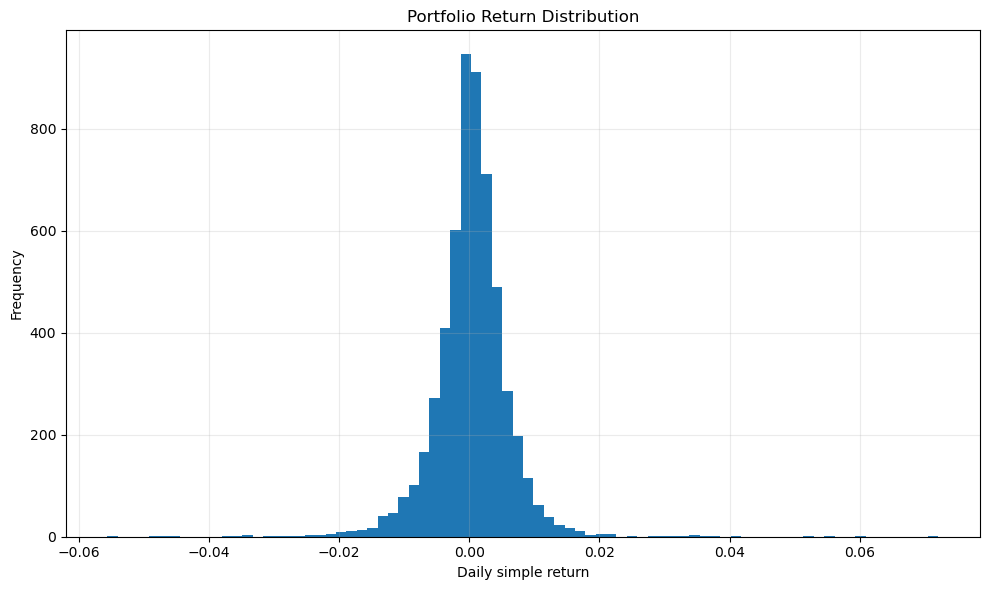

In [14]:
plt.figure(figsize=(10, 6))

plt.hist(
    portfolio_returns,
    bins=80,
)

plt.title("Portfolio Return Distribution")
plt.xlabel("Daily simple return")
plt.ylabel("Frequency")
plt.grid(alpha=0.25)

plt.tight_layout()

plt.savefig(
    FIGURES_DIR / "portfolio_return_distribution.png",
    dpi=200,
    bbox_inches="tight",
)

plt.show()

In [16]:
historical_results = historical_portfolio_report(
    log_returns=log_returns,
    weights=WEIGHTS,
    portfolio_value=PORTFOLIO_VALUE,
)

display(historical_results)

,Confidence_Level,VaR,Expected_Shortfall,Observations
0,0.950000,"8,606.100000","14,027.117021",5640
1,0.990000,"16,588.270000","24,555.859649",5640


In [17]:
parametric_results = parametric_portfolio_report(
    log_returns=log_returns,
    weights=WEIGHTS,
    portfolio_value=PORTFOLIO_VALUE,
)

display(parametric_results)

,Confidence_Level,VaR,Expected_Shortfall,Mean_Return,Volatility,Observations
0,0.950000,"9,566.469407","12,067.622063",0.000279,0.005986,5640
1,0.990000,"13,645.645420","15,673.975780",0.000279,0.005986,5640


In [18]:
historical_results = historical_portfolio_report(
    log_returns=log_returns,
    weights=WEIGHTS,
    portfolio_value=PORTFOLIO_VALUE,
)

parametric_results = parametric_portfolio_report(
    log_returns=log_returns,
    weights=WEIGHTS,
    portfolio_value=PORTFOLIO_VALUE,
)

var_es_comparison = pd.DataFrame({
    "Confidence_Level": historical_results["Confidence_Level"],
    "Historical_VaR": historical_results["VaR"],
    "Historical_ES": historical_results["Expected_Shortfall"],
    "Parametric_VaR": parametric_results["VaR"],
    "Parametric_ES": parametric_results["Expected_Shortfall"],
})

display(var_es_comparison)

,Confidence_Level,Historical_VaR,Historical_ES,Parametric_VaR,Parametric_ES
0,0.950000,"8,606.100000","14,027.117021","9,566.469407","12,067.622063"
1,0.990000,"16,588.270000","24,555.859649","13,645.645420","15,673.975780"


In [22]:
# Check the exact Monte Carlo function signature

import inspect
from src.risk.monte_carlo_portfolio import monte_carlo_portfolio_losses

print(inspect.signature(monte_carlo_portfolio_losses))

(log_returns: 'pd.DataFrame', weights: 'pd.Series', portfolio_value: 'float', n_simulations: 'int' = 100000, random_seed: 'int' = 42) -> 'pd.Series'


In [23]:
# Cell 11 — Monte Carlo VaR / ES

from src.risk.monte_carlo_portfolio import (
    monte_carlo_portfolio_losses,
)

mc_losses = monte_carlo_portfolio_losses(
    log_returns=log_returns,
    weights=WEIGHTS,
    portfolio_value=PORTFOLIO_VALUE,
    n_simulations=MONTE_CARLO_SIMULATIONS,
    random_seed=RANDOM_SEED,
)

mc_results = []

for confidence_level in CONFIDENCE_LEVELS:
    var = np.quantile(mc_losses, confidence_level)

    tail_losses = mc_losses[mc_losses >= var]
    expected_shortfall = tail_losses.mean()

    mc_results.append({
        "Confidence_Level": confidence_level,
        "Monte_Carlo_VaR": var,
        "Monte_Carlo_ES": expected_shortfall,
    })

mc_results = pd.DataFrame(mc_results)

display(mc_results)

,Confidence_Level,Monte_Carlo_VaR,Monte_Carlo_ES
0,0.950000,"9,587.009558","12,085.812702"
1,0.990000,"13,676.639723","15,699.787005"


In [24]:
# Cell 12 — VaR / ES model comparison

var_es_comparison = pd.DataFrame({
    "Confidence_Level": CONFIDENCE_LEVELS,

    "Historical_VaR": historical_results["VaR"].values,
    "Historical_ES": historical_results["Expected_Shortfall"].values,

    "Parametric_VaR": parametric_results["VaR"].values,
    "Parametric_ES": parametric_results["Expected_Shortfall"].values,

    "Monte_Carlo_VaR": mc_results["Monte_Carlo_VaR"].values,
    "Monte_Carlo_ES": mc_results["Monte_Carlo_ES"].values,
})

display(var_es_comparison)

# Save results
var_es_comparison.to_csv(
    PROJECT_ROOT / "results" / "tables" / "var_es_comparison.csv",
    index=False,
)

,Confidence_Level,Historical_VaR,Historical_ES,Parametric_VaR,Parametric_ES,Monte_Carlo_VaR,Monte_Carlo_ES
0,0.950000,"8,606.100000","14,027.117021","9,566.469407","12,067.622063","9,587.009558","12,085.812702"
1,0.990000,"16,588.270000","24,555.859649","13,645.645420","15,673.975780","13,676.639723","15,699.787005"


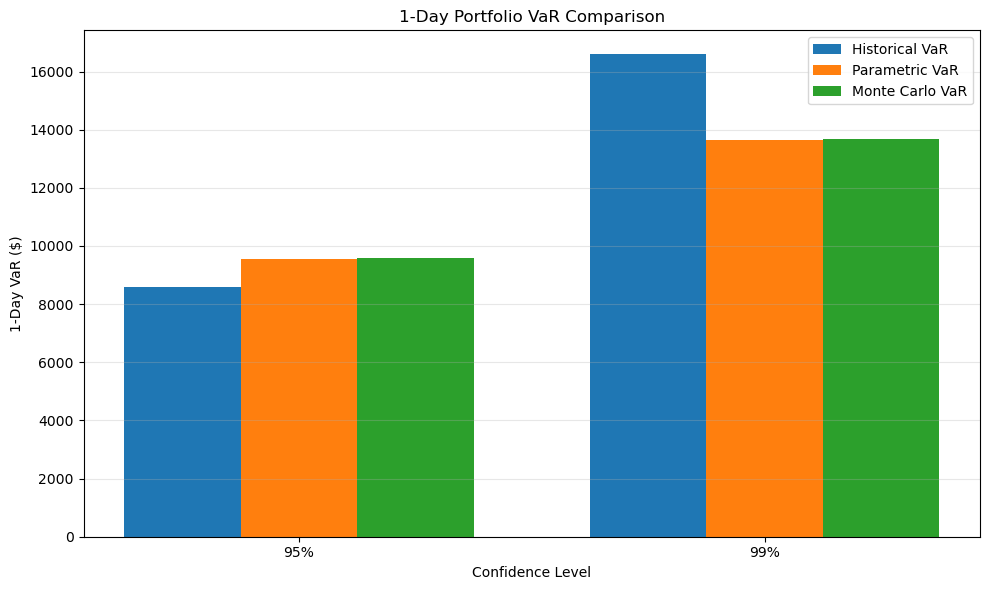

In [25]:
# Cell 13 — VaR comparison plot

fig, ax = plt.subplots(figsize=(10, 6))

x = np.arange(len(CONFIDENCE_LEVELS))
width = 0.25

ax.bar(
    x - width,
    var_es_comparison["Historical_VaR"],
    width,
    label="Historical VaR",
)

ax.bar(
    x,
    var_es_comparison["Parametric_VaR"],
    width,
    label="Parametric VaR",
)

ax.bar(
    x + width,
    var_es_comparison["Monte_Carlo_VaR"],
    width,
    label="Monte Carlo VaR",
)

ax.set_xlabel("Confidence Level")
ax.set_ylabel("1-Day VaR ($)")
ax.set_title("1-Day Portfolio VaR Comparison")
ax.set_xticks(x)
ax.set_xticklabels(
    [f"{level:.0%}" for level in CONFIDENCE_LEVELS]
)

ax.legend()
ax.grid(axis="y", alpha=0.3)

plt.tight_layout()

plt.savefig(
    PROJECT_ROOT / "results" / "figures" / "var_comparison.png",
    dpi=150,
    bbox_inches="tight",
)

plt.show()

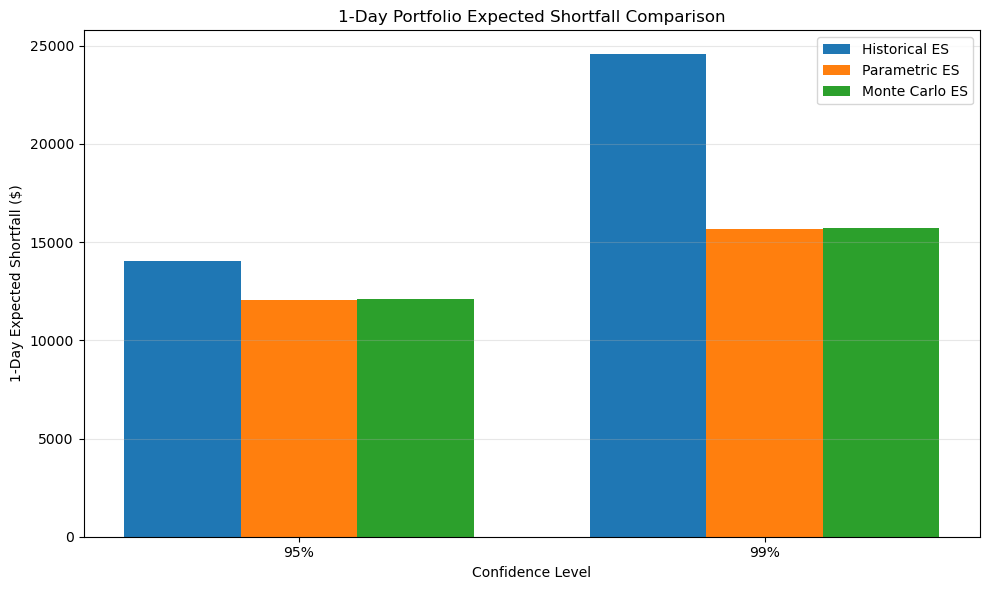

In [26]:
# Cell 14 — ES comparison plot

fig, ax = plt.subplots(figsize=(10, 6))

x = np.arange(len(CONFIDENCE_LEVELS))
width = 0.25

ax.bar(
    x - width,
    var_es_comparison["Historical_ES"],
    width,
    label="Historical ES",
)

ax.bar(
    x,
    var_es_comparison["Parametric_ES"],
    width,
    label="Parametric ES",
)

ax.bar(
    x + width,
    var_es_comparison["Monte_Carlo_ES"],
    width,
    label="Monte Carlo ES",
)

ax.set_xlabel("Confidence Level")
ax.set_ylabel("1-Day Expected Shortfall ($)")
ax.set_title("1-Day Portfolio Expected Shortfall Comparison")
ax.set_xticks(x)
ax.set_xticklabels(
    [f"{level:.0%}" for level in CONFIDENCE_LEVELS]
)

ax.legend()
ax.grid(axis="y", alpha=0.3)

plt.tight_layout()

plt.savefig(
    PROJECT_ROOT / "results" / "figures" / "es_comparison.png",
    dpi=150,
    bbox_inches="tight",
)

plt.show()

In [28]:
# Diagnostic — inspect rolling_historical_var signature

import inspect
from src.risk.rolling_var import rolling_historical_var

print(inspect.signature(rolling_historical_var))

(losses: 'pd.Series', confidence_level: 'float', window: 'int' = 756) -> 'pd.Series'


In [33]:
# Cell 15 — Rolling Historical VaR

from src.risk.rolling_var import rolling_historical_var_report
from src.risk.portfolio import portfolio_losses

ROLLING_WINDOW = 756
TRAIN_END = "2022-12-31"
TEST_START = "2023-01-01"

# Construct the complete portfolio loss series
portfolio_loss_series = portfolio_losses(
    log_returns=log_returns,
    weights=WEIGHTS,
    portfolio_value=PORTFOLIO_VALUE,
)

# Calculate rolling Historical VaR using the full historical series
rolling_historical_full = rolling_historical_var_report(
    losses=portfolio_loss_series,
    confidence_levels=CONFIDENCE_LEVELS,
    window=ROLLING_WINDOW,
)

# Keep only the out-of-sample test period
rolling_historical_results = rolling_historical_full.loc[TEST_START:]

display(rolling_historical_results.head())
display(rolling_historical_results.tail())

,VaR_95,VaR_99
Date,,
2023-01-02,"12,542.000000","22,911.700000"
2023-01-03,"12,542.000000","22,911.700000"
2023-01-04,"12,542.000000","22,911.700000"
2023-01-05,"12,542.000000","22,911.700000"
2023-01-06,"12,542.000000","22,911.700000"


,VaR_95,VaR_99
Date,,
2026-08-31,"8,239.750000","14,749.050000"
2026-09-01,"8,239.750000","14,749.050000"
2026-09-02,"8,193.750000","14,554.900000"
2026-09-03,"8,193.750000","14,554.900000"
2026-09-04,"8,193.750000","14,554.900000"


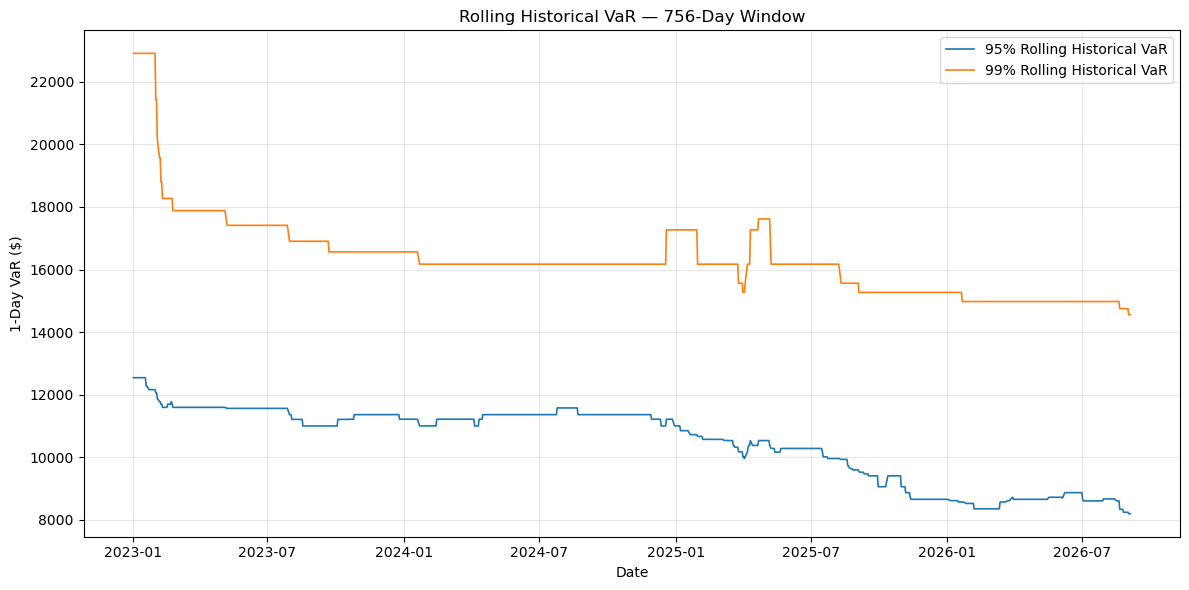

In [35]:
# Cell 16 — Rolling Historical VaR plot

fig, ax = plt.subplots(figsize=(12, 6))

ax.plot(
    rolling_historical_results.index,
    rolling_historical_results["VaR_95"],
    label="95% Rolling Historical VaR",
    linewidth=1.2,
)

ax.plot(
    rolling_historical_results.index,
    rolling_historical_results["VaR_99"],
    label="99% Rolling Historical VaR",
    linewidth=1.2,
)

ax.set_xlabel("Date")
ax.set_ylabel("1-Day VaR ($)")
ax.set_title("Rolling Historical VaR — 756-Day Window")

ax.legend()
ax.grid(alpha=0.3)

plt.tight_layout()

plt.savefig(
    PROJECT_ROOT / "results" / "figures" / "rolling_historical_var.png",
    dpi=150,
    bbox_inches="tight",
)

plt.show()

In [32]:
# Diagnostic — inspect rolling_historical_var_report

import inspect
from src.risk.rolling_var import rolling_historical_var_report

print(inspect.signature(rolling_historical_var_report))

(losses: 'pd.Series', confidence_levels: 'tuple[float, ...]' = (0.95, 0.99), window: 'int' = 756) -> 'pd.DataFrame'


In [36]:
# Cell 17 — Rolling Parametric VaR

from scipy.stats import norm

rolling_parametric_results = pd.DataFrame(
    index=rolling_historical_results.index,
    columns=["VaR_95", "VaR_99"],
    dtype=float,
)

portfolio_returns = -portfolio_loss_series / PORTFOLIO_VALUE

for date in rolling_parametric_results.index:
    position = portfolio_returns.index.get_loc(date)

    # Use only observations strictly before the current date
    start = max(0, position - ROLLING_WINDOW)
    training_returns = portfolio_returns.iloc[start:position].dropna()

    if len(training_returns) < ROLLING_WINDOW:
        continue

    mu = training_returns.mean()
    sigma = training_returns.std(ddof=1)

    for confidence_level in CONFIDENCE_LEVELS:
        z = norm.ppf(confidence_level)

        # Parametric VaR for a 1-day loss
        var = PORTFOLIO_VALUE * (z * sigma - mu)

        rolling_parametric_results.loc[
            date,
            f"VaR_{int(confidence_level * 100)}"
        ] = var

display(rolling_parametric_results.head())
display(rolling_parametric_results.tail())

,VaR_95,VaR_99
Date,,
2023-01-02,"12,978.795992","18,387.561060"
2023-01-03,"12,978.582490","18,387.363775"
2023-01-04,"12,978.941178","18,387.362492"
2023-01-05,"12,973.721152","18,383.716802"
2023-01-06,"12,981.690624","18,392.174536"


,VaR_95,VaR_99
Date,,
2026-08-31,"9,008.120038","12,945.034635"
2026-09-01,"9,004.199227","12,940.154680"
2026-09-02,"8,950.371267","12,869.824687"
2026-09-03,"8,948.413890","12,863.997714"
2026-09-04,"8,944.074323","12,861.431217"


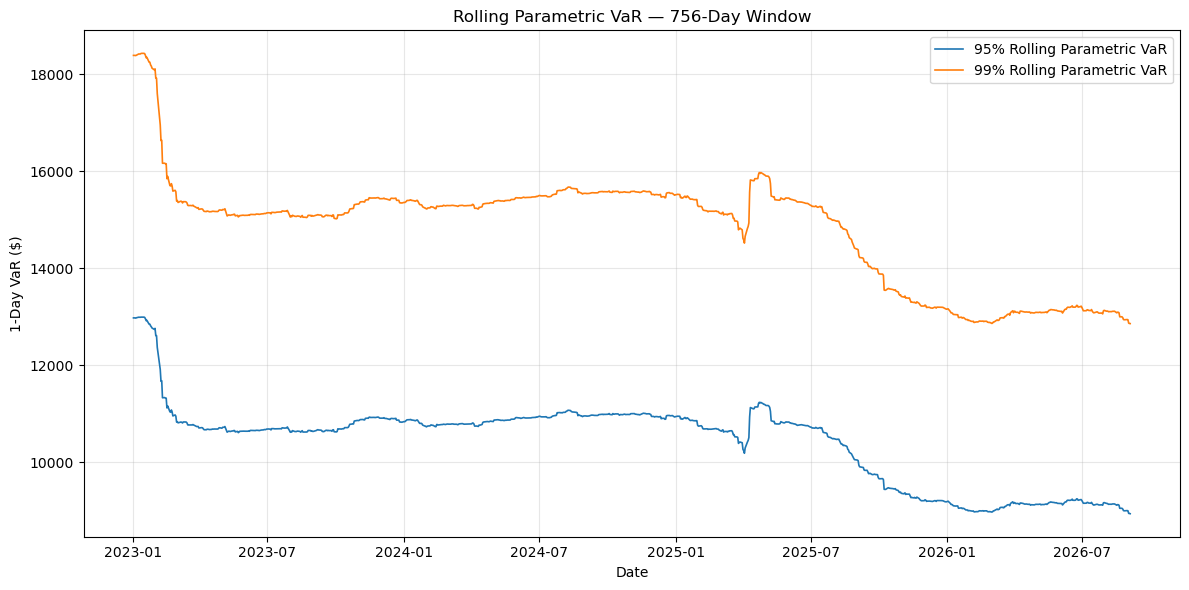

In [37]:
# Cell 18 — Rolling Parametric VaR plot

fig, ax = plt.subplots(figsize=(12, 6))

ax.plot(
    rolling_parametric_results.index,
    rolling_parametric_results["VaR_95"],
    label="95% Rolling Parametric VaR",
    linewidth=1.2,
)

ax.plot(
    rolling_parametric_results.index,
    rolling_parametric_results["VaR_99"],
    label="99% Rolling Parametric VaR",
    linewidth=1.2,
)

ax.set_xlabel("Date")
ax.set_ylabel("1-Day VaR ($)")
ax.set_title("Rolling Parametric VaR — 756-Day Window")

ax.legend()
ax.grid(alpha=0.3)

plt.tight_layout()

plt.savefig(
    PROJECT_ROOT / "results" / "figures" / "rolling_parametric_var.png",
    dpi=150,
    bbox_inches="tight",
)

plt.show()

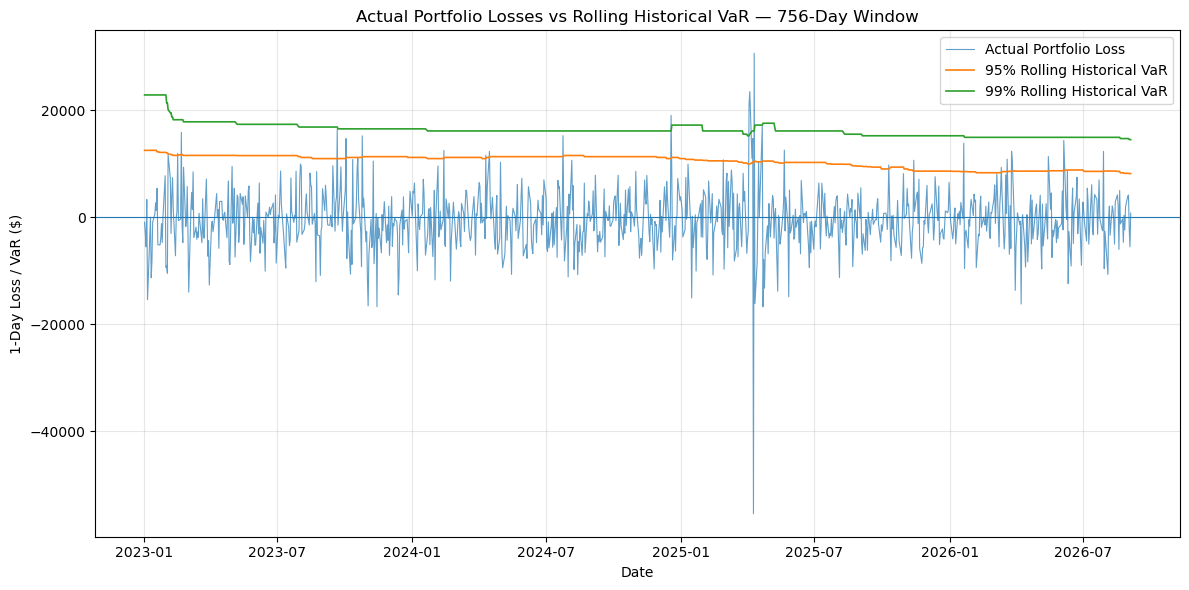

In [38]:
# Cell 19 — Actual Losses vs Rolling Historical VaR

test_losses = portfolio_loss_series.loc[rolling_historical_results.index]

fig, ax = plt.subplots(figsize=(12, 6))

ax.plot(
    test_losses.index,
    test_losses,
    label="Actual Portfolio Loss",
    linewidth=0.8,
    alpha=0.7,
)

ax.plot(
    rolling_historical_results.index,
    rolling_historical_results["VaR_95"],
    label="95% Rolling Historical VaR",
    linewidth=1.2,
)

ax.plot(
    rolling_historical_results.index,
    rolling_historical_results["VaR_99"],
    label="99% Rolling Historical VaR",
    linewidth=1.2,
)

ax.axhline(
    0,
    linewidth=0.8,
)

ax.set_xlabel("Date")
ax.set_ylabel("1-Day Loss / VaR ($)")
ax.set_title("Actual Portfolio Losses vs Rolling Historical VaR — 756-Day Window")

ax.legend()
ax.grid(alpha=0.3)

plt.tight_layout()

plt.savefig(
    PROJECT_ROOT / "results" / "figures" / "actual_loss_vs_var.png",
    dpi=150,
    bbox_inches="tight",
)

plt.show()

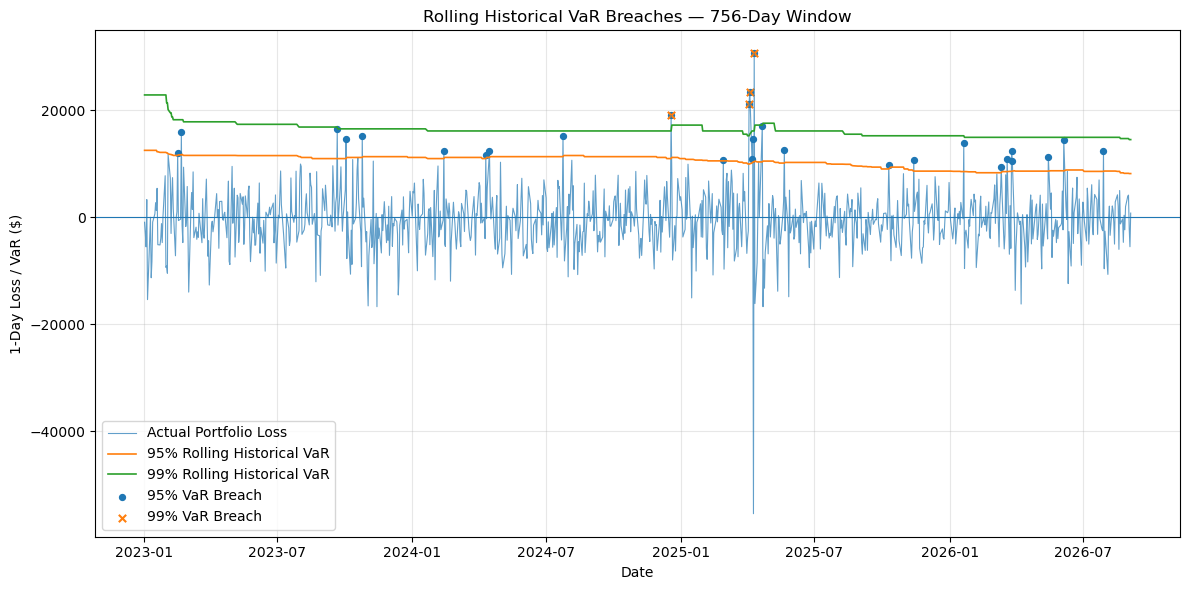

95% VaR breaches: 28
99% VaR breaches: 4
Total observations: 956


In [39]:
# Cell 20 — VaR Breach Visualization

breaches = pd.DataFrame(index=test_losses.index)

breaches["Actual_Loss"] = test_losses
breaches["VaR_95"] = rolling_historical_results["VaR_95"]
breaches["VaR_99"] = rolling_historical_results["VaR_99"]

breaches["Breach_95"] = breaches["Actual_Loss"] > breaches["VaR_95"]
breaches["Breach_99"] = breaches["Actual_Loss"] > breaches["VaR_99"]

fig, ax = plt.subplots(figsize=(12, 6))

ax.plot(
    breaches.index,
    breaches["Actual_Loss"],
    label="Actual Portfolio Loss",
    linewidth=0.8,
    alpha=0.7,
)

ax.plot(
    breaches.index,
    breaches["VaR_95"],
    label="95% Rolling Historical VaR",
    linewidth=1.2,
)

ax.plot(
    breaches.index,
    breaches["VaR_99"],
    label="99% Rolling Historical VaR",
    linewidth=1.2,
)

# Highlight 95% VaR breaches
ax.scatter(
    breaches.index[breaches["Breach_95"]],
    breaches.loc[breaches["Breach_95"], "Actual_Loss"],
    label="95% VaR Breach",
    s=18,
)

# Highlight 99% VaR breaches
ax.scatter(
    breaches.index[breaches["Breach_99"]],
    breaches.loc[breaches["Breach_99"], "Actual_Loss"],
    label="99% VaR Breach",
    s=28,
    marker="x",
)

ax.axhline(
    0,
    linewidth=0.8,
)

ax.set_xlabel("Date")
ax.set_ylabel("1-Day Loss / VaR ($)")
ax.set_title("Rolling Historical VaR Breaches — 756-Day Window")

ax.legend()
ax.grid(alpha=0.3)

plt.tight_layout()

plt.savefig(
    PROJECT_ROOT / "results" / "figures" / "var_breaches.png",
    dpi=150,
    bbox_inches="tight",
)

plt.show()

print("95% VaR breaches:", breaches["Breach_95"].sum())
print("99% VaR breaches:", breaches["Breach_99"].sum())
print("Total observations:", len(breaches))

In [42]:
# Cell 21 — Kupiec POF Backtest

from src.risk.kupiec import kupiec_pof_report

kupiec_exceptions = pd.DataFrame(index=breaches.index)

kupiec_exceptions["Exception_95"] = (
    breaches["Actual_Loss"] > breaches["VaR_95"]
).astype(int)

kupiec_exceptions["Exception_99"] = (
    breaches["Actual_Loss"] > breaches["VaR_99"]
).astype(int)

kupiec_backtest = kupiec_pof_report(
    exceptions=pd.Series(
        kupiec_exceptions["Exception_95"],
        index=kupiec_exceptions.index,
    ),
    confidence_levels=(0.95,),
)

kupiec_99 = kupiec_pof_report(
    exceptions=pd.Series(
        kupiec_exceptions["Exception_99"],
        index=kupiec_exceptions.index,
    ),
    confidence_levels=(0.99,),
)

kupiec_backtest = pd.concat(
    [kupiec_backtest, kupiec_99],
    ignore_index=True,
)

display(kupiec_backtest)

kupiec_backtest.to_csv(
    PROJECT_ROOT / "results" / "tables" / "kupiec_backtest.csv",
    index=False,
)

,observations,exceptions,observed_exception_rate,expected_exception_rate,lr_statistic,p_value
0,956.000000,28.000000,0.029289,0.050000,10.078581,0.001500
1,956.000000,4.000000,0.004184,0.010000,4.182252,0.040849


In [44]:
# Cell 22 — Christoffersen Independence & Conditional Coverage

from src.risk.christoffersen import christoffersen_report

christoffersen_95 = christoffersen_report(
    exceptions=pd.Series(
        kupiec_exceptions["Exception_95"],
        index=kupiec_exceptions.index,
    ),
    confidence_levels=(0.95,),
)

christoffersen_99 = christoffersen_report(
    exceptions=pd.Series(
        kupiec_exceptions["Exception_99"],
        index=kupiec_exceptions.index,
    ),
    confidence_levels=(0.99,),
)

christoffersen_backtest = pd.concat(
    [christoffersen_95, christoffersen_99],
    ignore_index=True,
)

display(christoffersen_backtest)

christoffersen_backtest.to_csv(
    PROJECT_ROOT / "results" / "tables" / "christoffersen_backtest.csv",
    index=False,
)

,n00,n01,n10,n11,pi,pi01,pi11,lr_independence,p_value_independence,lr_coverage,p_value_coverage
0,903.000000,24.000000,24.000000,4.000000,0.029319,0.025890,0.142857,7.096388,0.007724,17.174969,0.000186
1,948.000000,3.000000,3.000000,1.000000,0.004188,0.003155,0.250000,6.743940,0.009407,10.926193,0.004240


In [47]:
# Cell 23 — Conditional Coverage Summary

conditional_coverage = pd.DataFrame({
    "Confidence_Level": CONFIDENCE_LEVELS,
    "LR_Independence": christoffersen_backtest["lr_independence"].values,
    "p_value_Independence": christoffersen_backtest["p_value_independence"].values,
    "LR_Conditional_Coverage": christoffersen_backtest["lr_coverage"].values,
    "p_value_Conditional_Coverage": christoffersen_backtest["p_value_coverage"].values,
})

display(conditional_coverage)

conditional_coverage.to_csv(
    PROJECT_ROOT / "results" / "tables" / "conditional_coverage.csv",
    index=False,
)

,Confidence_Level,LR_Independence,p_value_Independence,LR_Conditional_Coverage,p_value_Conditional_Coverage
0,0.950000,7.096388,0.007724,17.174969,0.000186
1,0.990000,6.743940,0.009407,10.926193,0.004240


In [49]:
# Cell 24 — GARCH Conditional VaR

from src.risk.garch_var import garch_conditional_var

portfolio_simple_returns = -portfolio_loss_series / PORTFOLIO_VALUE

garch_var_results = {}

for confidence_level in CONFIDENCE_LEVELS:
    garch_var_results[confidence_level] = garch_conditional_var(
        returns=portfolio_simple_returns,
        portfolio_value=PORTFOLIO_VALUE,
        confidence_level=confidence_level,
    )

garch_conditional_var_results = pd.DataFrame(
    garch_var_results,
    index=portfolio_simple_returns.index,
)

garch_conditional_var_results.columns = [
    f"VaR_{int(level * 100)}"
    for level in CONFIDENCE_LEVELS
]

# Keep only the out-of-sample period
garch_conditional_var_results = (
    garch_conditional_var_results.loc[TEST_START:]
)

display(garch_conditional_var_results.head())
display(garch_conditional_var_results.tail())

,VaR_95,VaR_99
Date,,
2023-01-02,"12,704.361125","17,968.020382"
2023-01-03,"11,980.009362","16,943.555860"
2023-01-04,"11,384.501198","16,101.317300"
2023-01-05,"11,080.821401","15,671.817168"
2023-01-06,"10,651.015218","15,063.934081"


,VaR_95,VaR_99
Date,,
2026-08-31,"6,475.025266","9,157.751800"
2026-09-01,"6,609.852548","9,348.440597"
2026-09-02,"6,765.599317","9,568.716225"
2026-09-03,"6,514.654413","9,213.800058"
2026-09-04,"6,779.101529","9,587.812661"


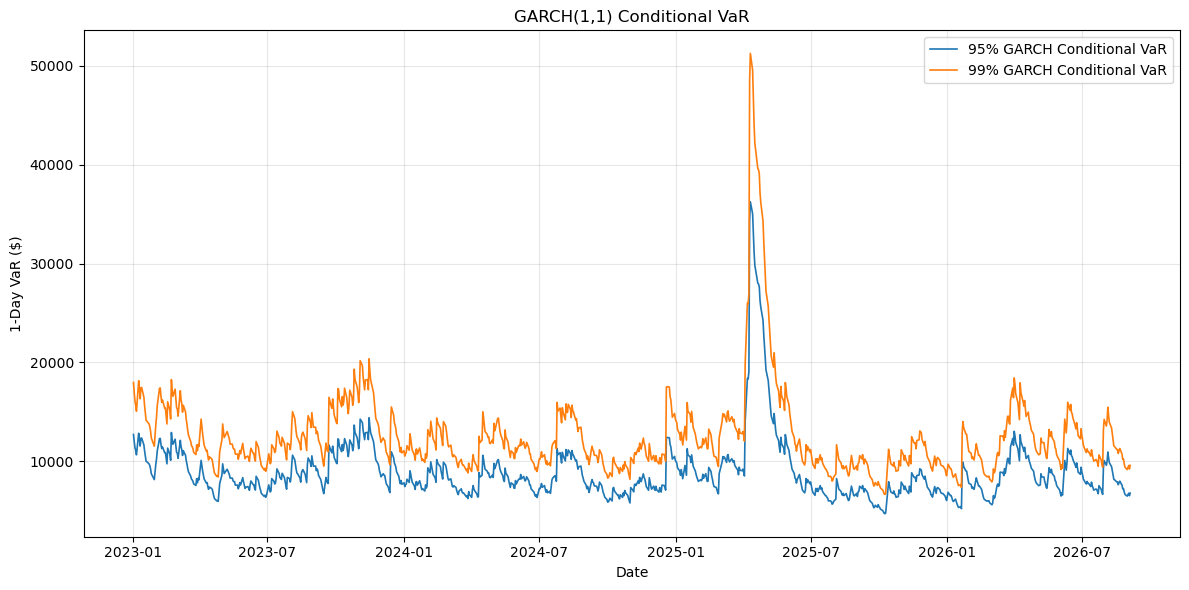

In [50]:
# Cell 25 — GARCH Conditional VaR Plot

fig, ax = plt.subplots(figsize=(12, 6))

ax.plot(
    garch_conditional_var_results.index,
    garch_conditional_var_results["VaR_95"],
    label="95% GARCH Conditional VaR",
    linewidth=1.2,
)

ax.plot(
    garch_conditional_var_results.index,
    garch_conditional_var_results["VaR_99"],
    label="99% GARCH Conditional VaR",
    linewidth=1.2,
)

ax.set_xlabel("Date")
ax.set_ylabel("1-Day VaR ($)")
ax.set_title("GARCH(1,1) Conditional VaR")

ax.legend()
ax.grid(alpha=0.3)

plt.tight_layout()

plt.savefig(
    PROJECT_ROOT / "results" / "figures" / "garch_conditional_var.png",
    dpi=150,
    bbox_inches="tight",
)

plt.show()

In [52]:
# Cell 26 — GARCH vs GJR-GARCH Volatility Comparison

from src.risk.garch_var import garch_conditional_volatility
from src.risk.gjr_garch import gjr_garch_conditional_volatility

portfolio_simple_returns = -portfolio_loss_series / PORTFOLIO_VALUE

garch_volatility = garch_conditional_volatility(
    returns=portfolio_simple_returns
)

gjr_volatility = gjr_garch_conditional_volatility(
    returns=portfolio_simple_returns
)

garch_gjr_volatility = pd.DataFrame({
    "GARCH_11_Volatility": garch_volatility,
    "GJR_GARCH_Volatility": gjr_volatility,
}).loc[TEST_START:]

display(garch_gjr_volatility.head())
display(garch_gjr_volatility.tail())

garch_gjr_volatility.to_csv(
    PROJECT_ROOT / "results" / "tables" / "garch_vs_gjr_comparison.csv"
)

,GARCH_11_Volatility,GJR_GARCH_Volatility
Date,,
2023-01-02,0.007724,0.007898
2023-01-03,0.007283,0.007551
2023-01-04,0.006921,0.007228
2023-01-05,0.006737,0.006942
2023-01-06,0.006475,0.006779


,GARCH_11_Volatility,GJR_GARCH_Volatility
Date,,
2026-08-31,0.003937,0.003954
2026-09-01,0.004019,0.004137
2026-09-02,0.004113,0.004326
2026-09-03,0.003961,0.004178
2026-09-04,0.004121,0.004079


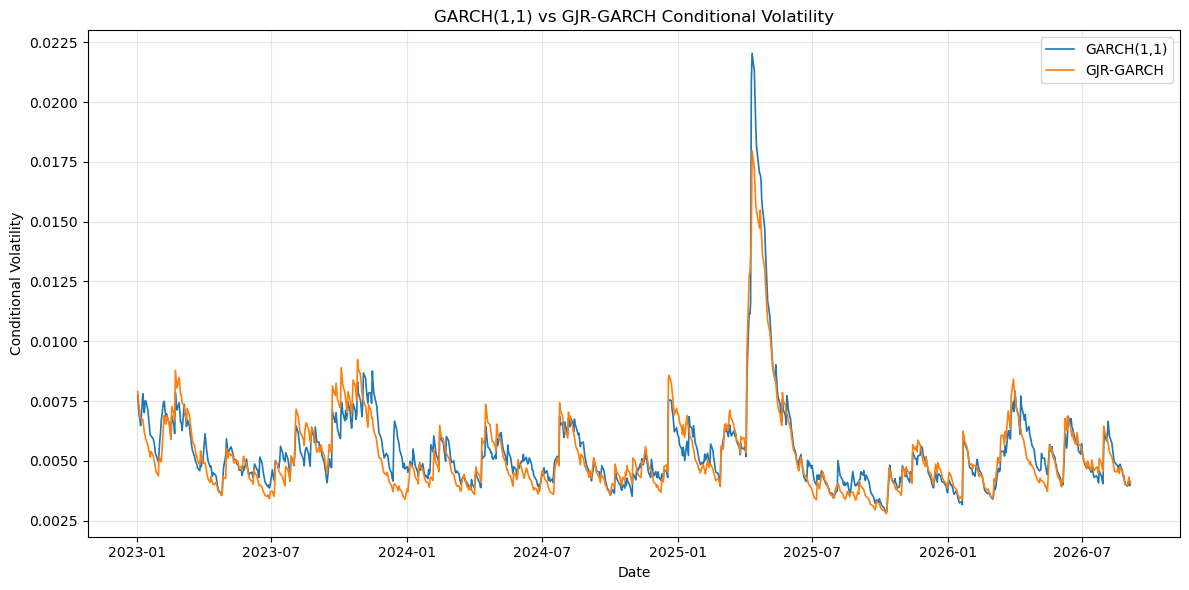

In [53]:
fig, ax = plt.subplots(figsize=(12, 6))

ax.plot(
    garch_gjr_volatility.index,
    garch_gjr_volatility["GARCH_11_Volatility"],
    label="GARCH(1,1)",
    linewidth=1.2,
)

ax.plot(
    garch_gjr_volatility.index,
    garch_gjr_volatility["GJR_GARCH_Volatility"],
    label="GJR-GARCH",
    linewidth=1.2,
)

ax.set_xlabel("Date")
ax.set_ylabel("Conditional Volatility")
ax.set_title("GARCH(1,1) vs GJR-GARCH Conditional Volatility")

ax.legend()
ax.grid(alpha=0.3)

plt.tight_layout()

plt.savefig(
    PROJECT_ROOT / "results" / "figures" / "garch_vs_gjr_volatility.png",
    dpi=150,
    bbox_inches="tight",
)

plt.show()

In [54]:
# Cell 27 — GARCH vs GJR-GARCH VaR Comparison

from src.risk.garch_var import garch_conditional_var
from src.risk.gjr_garch import gjr_garch_conditional_var

garch_var_comparison = {}
gjr_var_comparison = {}

for confidence_level in CONFIDENCE_LEVELS:
    garch_var_comparison[confidence_level] = garch_conditional_var(
        returns=portfolio_simple_returns,
        portfolio_value=PORTFOLIO_VALUE,
        confidence_level=confidence_level,
    )

    gjr_var_comparison[confidence_level] = gjr_garch_conditional_var(
        returns=portfolio_simple_returns,
        portfolio_value=PORTFOLIO_VALUE,
        confidence_level=confidence_level,
    )

garch_vs_gjr_var = pd.DataFrame(index=portfolio_simple_returns.index)

for confidence_level in CONFIDENCE_LEVELS:
    level = int(confidence_level * 100)

    garch_vs_gjr_var[f"GARCH_VaR_{level}"] = (
        garch_var_comparison[confidence_level]
    )

    garch_vs_gjr_var[f"GJR_GARCH_VaR_{level}"] = (
        gjr_var_comparison[confidence_level]
    )

garch_vs_gjr_var = garch_vs_gjr_var.loc[TEST_START:]

display(garch_vs_gjr_var.head())
display(garch_vs_gjr_var.tail())

garch_vs_gjr_var.to_csv(
    PROJECT_ROOT / "results" / "tables" / "garch_vs_gjr_var.csv",
)

,GARCH_VaR_95,GJR_GARCH_VaR_95,GARCH_VaR_99,GJR_GARCH_VaR_99
Date,,,,
2023-01-02,"12,704.361125","12,990.968708","17,968.020382","18,373.374956"
2023-01-03,"11,980.009362","12,419.552193","16,943.555860","17,565.209674"
2023-01-04,"11,384.501198","11,888.795164","16,101.317300","16,814.549879"
2023-01-05,"11,080.821401","11,418.871682","15,671.817168","16,149.928131"
2023-01-06,"10,651.015218","11,150.485457","15,063.934081","15,770.344371"


,GARCH_VaR_95,GJR_GARCH_VaR_95,GARCH_VaR_99,GJR_GARCH_VaR_99
Date,,,,
2026-08-31,"6,475.025266","6,504.260490","9,157.751800","9,199.099734"
2026-09-01,"6,609.852548","6,805.404709","9,348.440597","9,625.013750"
2026-09-02,"6,765.599317","7,115.556733","9,568.716225","10,063.667676"
2026-09-03,"6,514.654413","6,871.380704","9,213.800058","9,718.324859"
2026-09-04,"6,779.101529","6,709.104507","9,587.812661","9,488.814537"


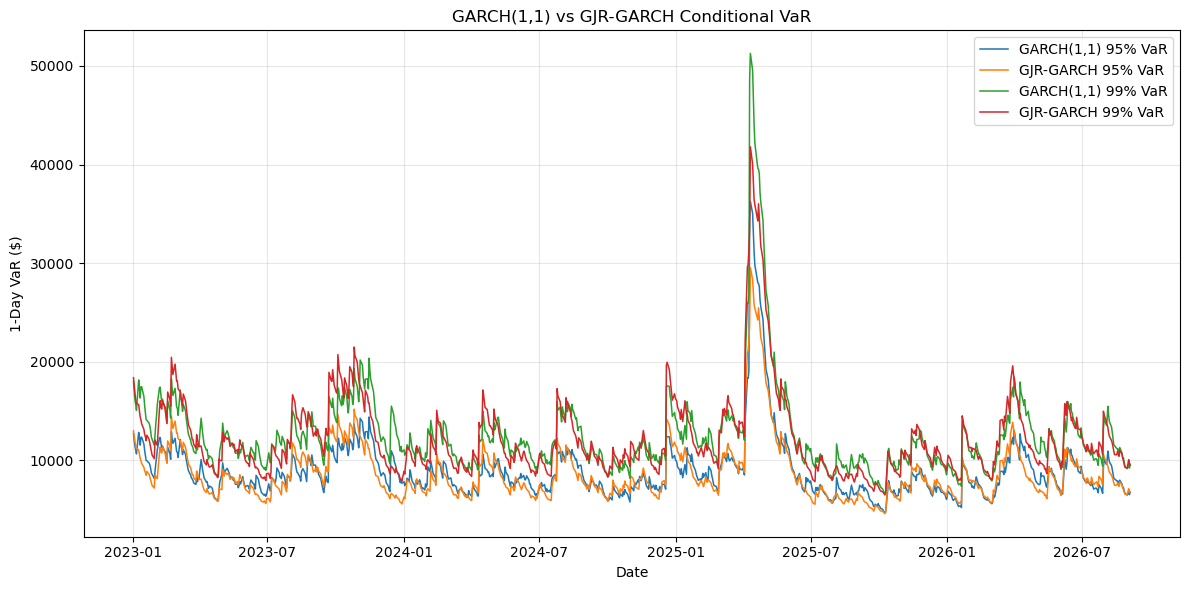

In [55]:
# Cell 28 — GARCH vs GJR-GARCH VaR Plot

fig, ax = plt.subplots(figsize=(12, 6))

ax.plot(
    garch_vs_gjr_var.index,
    garch_vs_gjr_var["GARCH_VaR_95"],
    label="GARCH(1,1) 95% VaR",
    linewidth=1.1,
)

ax.plot(
    garch_vs_gjr_var.index,
    garch_vs_gjr_var["GJR_GARCH_VaR_95"],
    label="GJR-GARCH 95% VaR",
    linewidth=1.1,
)

ax.plot(
    garch_vs_gjr_var.index,
    garch_vs_gjr_var["GARCH_VaR_99"],
    label="GARCH(1,1) 99% VaR",
    linewidth=1.1,
)

ax.plot(
    garch_vs_gjr_var.index,
    garch_vs_gjr_var["GJR_GARCH_VaR_99"],
    label="GJR-GARCH 99% VaR",
    linewidth=1.1,
)

ax.set_xlabel("Date")
ax.set_ylabel("1-Day VaR ($)")
ax.set_title("GARCH(1,1) vs GJR-GARCH Conditional VaR")

ax.legend()
ax.grid(alpha=0.3)

plt.tight_layout()

plt.savefig(
    PROJECT_ROOT / "results" / "figures" / "garch_vs_gjr_var.png",
    dpi=150,
    bbox_inches="tight",
)

plt.show()

In [58]:
# Cell 29 — Historical Stress Testing

from src.risk.historical_stress import historical_stress_report

STRESS_PERIODS = {
    "Global_Financial_Crisis": ("2008-01-01", "2009-03-31"),
    "COVID_19_Shock": ("2020-02-01", "2020-05-31"),
    "2022_Market_Stress": ("2022-01-01", "2022-12-31"),
}

historical_stress_results = historical_stress_report(
    returns=log_returns,
    weights=WEIGHTS,
    portfolio_value=PORTFOLIO_VALUE,
    stress_periods=STRESS_PERIODS,
)

display(historical_stress_results)

historical_stress_results.to_csv(
    PROJECT_ROOT / "results" / "tables" / "historical_stress_results.csv",
    index=False,
)

,observations,cumulative_return,annualized_volatility,worst_daily_return,worst_daily_loss,maximum_drawdown,cumulative_pnl,worst_daily_loss_dollars,maximum_drawdown_dollars
period,,,,,,,,,
Global_Financial_Crisis,316,-0.191497,0.210627,-0.055616,0.055616,-0.275114,"-191,497.186043","55,616.367413","-275,113.583344"
COVID_19_Shock,85,0.032168,0.229643,-0.046951,0.046951,-0.146273,"32,168.350405","46,951.367179","-146,272.586988"
2022_Market_Stress,260,-0.191784,0.139238,-0.030831,0.030831,-0.236750,"-191,784.075242","30,831.447695","-236,750.270145"


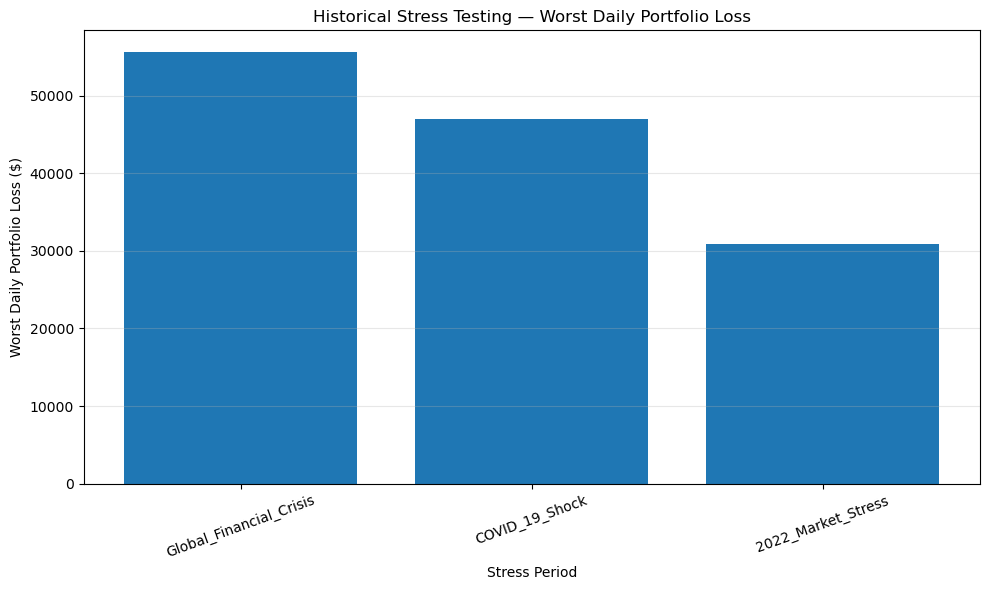

In [61]:
# Cell 29 — Historical Stress Comparison Plot

fig, ax = plt.subplots(figsize=(10, 6))

ax.bar(
    historical_stress_results.index,
    historical_stress_results["worst_daily_loss_dollars"],
)

ax.set_xlabel("Stress Period")
ax.set_ylabel("Worst Daily Portfolio Loss ($)")
ax.set_title("Historical Stress Testing — Worst Daily Portfolio Loss")

ax.tick_params(axis="x", rotation=20)
ax.grid(axis="y", alpha=0.3)

plt.tight_layout()

plt.savefig(
    PROJECT_ROOT / "results" / "figures" / "historical_stress_comparison.png",
    dpi=150,
    bbox_inches="tight",
)

plt.show()

In [62]:
# Cell 30 — Hypothetical Stress Testing

from src.risk.hypothetical_stress import hypothetical_stress_report

HYPOTHETICAL_SCENARIOS = {
    "Moderate_Shock": {
        "SPY": -0.10,
        "EURUSD": -0.05,
        "TLT": -0.08,
    },
    "Severe_Shock": {
        "SPY": -0.15,
        "EURUSD": -0.10,
        "TLT": -0.10,
    },
}

hypothetical_stress_results = hypothetical_stress_report(
    weights=WEIGHTS,
    scenarios=HYPOTHETICAL_SCENARIOS,
    portfolio_value=PORTFOLIO_VALUE,
)

display(hypothetical_stress_results)

hypothetical_stress_results.to_csv(
    PROJECT_ROOT / "results" / "tables" / "hypothetical_stress_results.csv",
    index=False,
)

,portfolio_return,portfolio_loss,portfolio_value,portfolio_value_before,portfolio_value_after,loss_percentage
scenario,,,,,,
Moderate_Shock,-0.084000,"84,000.000000","1,000,000.000000","1,000,000.000000","916,000.000000",0.084000
Severe_Shock,-0.125000,"125,000.000000","1,000,000.000000","1,000,000.000000","875,000.000000",0.125000


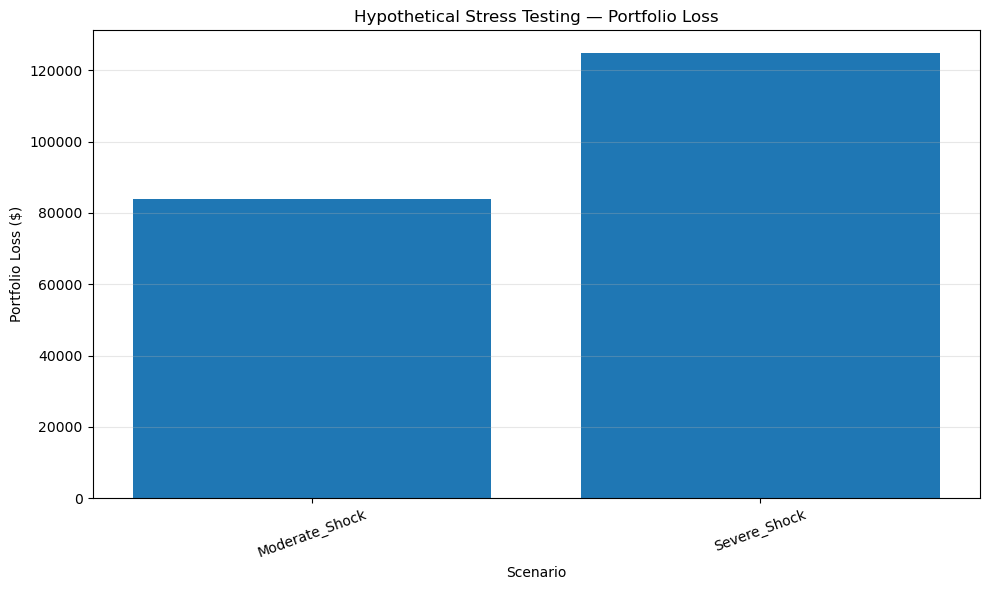

In [63]:
# Cell 24 — Hypothetical Stress Loss Plot

fig, ax = plt.subplots(figsize=(10, 6))

ax.bar(
    hypothetical_stress_results.index,
    hypothetical_stress_results["portfolio_loss"],
)

ax.set_xlabel("Scenario")
ax.set_ylabel("Portfolio Loss ($)")
ax.set_title("Hypothetical Stress Testing — Portfolio Loss")

ax.tick_params(axis="x", rotation=20)
ax.grid(axis="y", alpha=0.3)

plt.tight_layout()

plt.savefig(
    PROJECT_ROOT / "results" / "figures" / "hypothetical_stress_losses.png",
    dpi=150,
    bbox_inches="tight",
)

plt.show()

In [64]:
# Cell 25 — Final Risk Summary

step10_summary = pd.DataFrame({
    "Metric": [
        "Historical VaR 95%",
        "Historical VaR 99%",
        "Parametric VaR 95%",
        "Parametric VaR 99%",
        "Monte Carlo VaR 95%",
        "Monte Carlo VaR 99%",
        "GARCH VaR 95%",
        "GARCH VaR 99%",
    ],
    "Value": [
        historical_results.loc[
            historical_results["Confidence_Level"] == 0.95,
            "VaR",
        ].iloc[0],

        historical_results.loc[
            historical_results["Confidence_Level"] == 0.99,
            "VaR",
        ].iloc[0],

        parametric_results.loc[
            parametric_results["Confidence_Level"] == 0.95,
            "VaR",
        ].iloc[0],

        parametric_results.loc[
            parametric_results["Confidence_Level"] == 0.99,
            "VaR",
        ].iloc[0],

        mc_results.loc[
            mc_results["Confidence_Level"] == 0.95,
            "Monte_Carlo_VaR",
        ].iloc[0],

        mc_results.loc[
            mc_results["Confidence_Level"] == 0.99,
            "Monte_Carlo_VaR",
        ].iloc[0],

        garch_conditional_var_results["VaR_95"].dropna().iloc[-1],

        garch_conditional_var_results["VaR_99"].dropna().iloc[-1],
    ],
})

display(step10_summary)

step10_summary.to_csv(
    PROJECT_ROOT / "results" / "tables" / "step10_summary.csv",
    index=False,
)

,Metric,Value
0,Historical VaR 95%,"8,606.100000"
1,Historical VaR 99%,"16,588.270000"
2,Parametric VaR 95%,"9,566.469407"
3,Parametric VaR 99%,"13,645.645420"
4,Monte Carlo VaR 95%,"9,587.009558"
5,Monte Carlo VaR 99%,"13,676.639723"
6,GARCH VaR 95%,"6,779.101529"
7,GARCH VaR 99%,"9,587.812661"


## 26. Limitations

This framework provides a practical multi-asset market-risk analysis, but several limitations should be considered when interpreting the results.

### 1. Historical-data dependence
Historical VaR and Expected Shortfall depend strongly on the historical return sample. Future market conditions may differ substantially from the periods represented in the data.

### 2. Distributional assumptions
Parametric VaR assumes a specified distribution for portfolio returns. Financial returns can exhibit fat tails, skewness, and other characteristics that may not be fully captured by a normal-distribution assumption.

### 3. Monte Carlo assumptions
Monte Carlo risk estimates depend on the assumed return-generating process and covariance structure. Multivariate normal simulation may underestimate extreme dependence and tail behavior.

### 4. Volatility-model limitations
GARCH(1,1) and GJR-GARCH model conditional volatility but do not capture every source of market dependence. GJR-GARCH additionally models asymmetric responses to positive and negative shocks, but its performance remains model- and sample-dependent.

### 5. Stress-testing limitations
Historical stress tests describe portfolio behavior during selected historical episodes and should not be interpreted as forecasts. Hypothetical scenarios are illustrative assumptions rather than predictions of future market movements.

### 6. Data-quality limitations
Short gaps in the underlying market data are forward-filled during preprocessing. This can introduce synthetic zero-return observations and should be considered when interpreting volatility and risk estimates.

### 7. Portfolio assumptions
The analysis assumes a fixed portfolio value of $1,000,000, fixed asset weights, a one-day risk horizon, daily rebalancing, and no transaction costs or market-impact effects.

### 8. Liquidity and transaction costs
The framework does not explicitly model liquidity risk, bid-ask spreads, market impact, funding costs, or transaction costs.

### 9. Model risk
No single risk model should be considered universally superior. Historical, parametric, Monte Carlo, GARCH, and GJR-GARCH approaches capture different aspects of portfolio risk and should be interpreted together.

### 10. Risk-free-rate assumption
A zero risk-free rate is used for the exploratory portfolio analysis. This simplifies the framework and may differ from the assumptions used in a production risk-management system.

### Overall limitation
The framework should therefore be viewed as a research and educational market-risk engine rather than a production risk-management system. A production implementation would require stronger data-quality controls, liquidity modeling, transaction-cost modeling, richer dependence structures, model governance, monitoring, and independent validation.

In [69]:
rolling_var_summary = pd.DataFrame({
    "Metric": [
        "Rolling Historical VaR 95%",
        "Rolling Historical VaR 99%",
        "Rolling Parametric VaR 95%",
        "Rolling Parametric VaR 99%",
    ],
    "Mean_VaR": [
        rolling_historical_results["VaR_95"].mean(),
        rolling_historical_results["VaR_99"].mean(),
        rolling_parametric_results["VaR_95"].mean(),
        rolling_parametric_results["VaR_99"].mean(),
    ],
    "Maximum_VaR": [
        rolling_historical_results["VaR_95"].max(),
        rolling_historical_results["VaR_99"].max(),
        rolling_parametric_results["VaR_95"].max(),
        rolling_parametric_results["VaR_99"].max(),
    ],
    "Minimum_VaR": [
        rolling_historical_results["VaR_95"].min(),
        rolling_historical_results["VaR_99"].min(),
        rolling_parametric_results["VaR_95"].min(),
        rolling_parametric_results["VaR_99"].min(),
    ],
})

rolling_var_summary.to_csv(
    PROJECT_ROOT / "results" / "tables" / "rolling_var_summary.csv",
    index=False,
)

rolling_var_summary

,Metric,Mean_VaR,Maximum_VaR,Minimum_VaR
0,Rolling Historical VaR 95%,"10,478.540533","12,542.000000","8,193.750000"
1,Rolling Historical VaR 99%,"16,353.809048","22,911.700000","14,554.900000"
2,Rolling Parametric VaR 95%,"10,429.049422","12,994.834517","8,944.074323"
3,Rolling Parametric VaR 99%,"14,833.139522","18,429.860917","12,861.431217"


In [71]:
garch_var_summary = pd.DataFrame({
    "Metric": [
        "GARCH VaR 95%",
        "GARCH VaR 99%",
    ],
    "Mean_VaR": [
        garch_conditional_var_results["VaR_95"].mean(),
        garch_conditional_var_results["VaR_99"].mean(),
    ],
    "Maximum_VaR": [
        garch_conditional_var_results["VaR_95"].max(),
        garch_conditional_var_results["VaR_99"].max(),
    ],
    "Minimum_VaR": [
        garch_conditional_var_results["VaR_95"].min(),
        garch_conditional_var_results["VaR_99"].min(),
    ],
})

garch_var_summary.to_csv(
    PROJECT_ROOT / "results" / "tables" / "garch_var_summary.csv",
    index=False,
)

garch_var_summary

,Metric,Mean_VaR,Maximum_VaR,Minimum_VaR
0,GARCH VaR 95%,"8,865.966855","36,252.837985","4,693.850987"
1,GARCH VaR 99%,"12,539.306116","51,273.080591","6,638.603026"


In [73]:
# GARCH vs GJR-GARCH backtesting

actual_losses_test = portfolio_loss_series.loc[TEST_START:]

garch_backtest = pd.DataFrame({
    "Actual_Loss": actual_losses_test,
    "GARCH_VaR_95": garch_vs_gjr_var.loc[TEST_START:, "GARCH_VaR_95"],
    "GJR_GARCH_VaR_95": garch_vs_gjr_var.loc[TEST_START:, "GJR_GARCH_VaR_95"],
    "GARCH_VaR_99": garch_vs_gjr_var.loc[TEST_START:, "GARCH_VaR_99"],
    "GJR_GARCH_VaR_99": garch_vs_gjr_var.loc[TEST_START:, "GJR_GARCH_VaR_99"],
}).dropna()

garch_vs_gjr_backtesting = pd.DataFrame({
    "Model": [
        "GARCH(1,1)",
        "GJR-GARCH",
    ],
    "VaR_95_Breaches": [
        (garch_backtest["Actual_Loss"] > garch_backtest["GARCH_VaR_95"]).sum(),
        (garch_backtest["Actual_Loss"] > garch_backtest["GJR_GARCH_VaR_95"]).sum(),
    ],
    "VaR_99_Breaches": [
        (garch_backtest["Actual_Loss"] > garch_backtest["GARCH_VaR_99"]).sum(),
        (garch_backtest["Actual_Loss"] > garch_backtest["GJR_GARCH_VaR_99"]).sum(),
    ],
    "Observations": len(garch_backtest),
})

garch_vs_gjr_backtesting["Breach_Rate_95"] = (
    garch_vs_gjr_backtesting["VaR_95_Breaches"]
    / garch_vs_gjr_backtesting["Observations"]
)

garch_vs_gjr_backtesting["Breach_Rate_99"] = (
    garch_vs_gjr_backtesting["VaR_99_Breaches"]
    / garch_vs_gjr_backtesting["Observations"]
)

garch_vs_gjr_backtesting.to_csv(
    PROJECT_ROOT / "results" / "tables" / "garch_vs_gjr_backtesting.csv",
    index=False,
)

garch_vs_gjr_backtesting

,Model,VaR_95_Breaches,VaR_99_Breaches,Observations,Breach_Rate_95,Breach_Rate_99
0,"GARCH(1,1)",48,19,956,0.050209,0.019874
1,GJR-GARCH,52,16,956,0.054393,0.016736
